# Домашняя работа №5


Выполнил: Шалыгин Н.А

Группа: ФПэ-01-22

----------------------------------------------------------------------------------------------------------------

Отрисовать рабочую лопатку регулирующей ступени из курсового проекта в 3D при помощи matplotlib

# Построение самого профиля 

In [1]:

%reload_ext autoreload
%autoreload 2

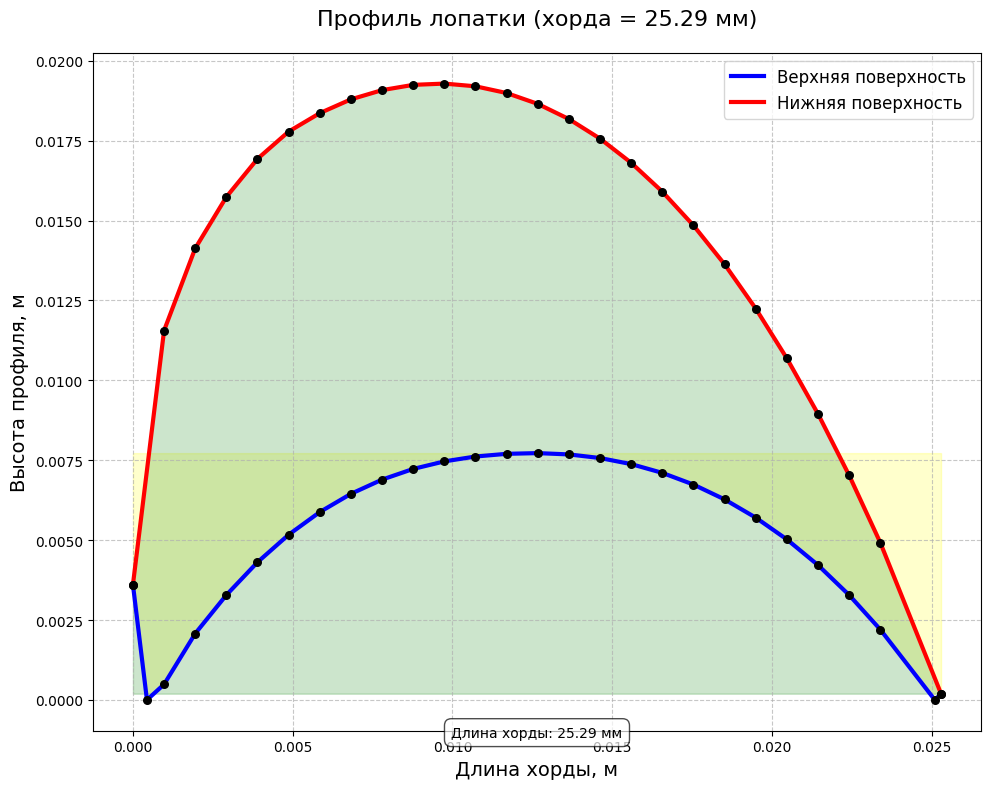

Масштабирующий коэффициент: 0.9746
Проверка длины хорды: 0.02529 м


In [1]:
import numpy as np
import matplotlib.pyplot as plt

xu_raw = np.array([0,0.45,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25.75,25.95])/1000
xl_raw = np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25.95])/1000
yu_raw = np.array([3.7,0.0,0.5,2.13,3.368,4.422,5.305,6.032,6.617,7.074,7.417,7.659,7.816,7.902,7.925,7.883,7.767,7.572,7.29,6.915,6.438,5.853,5.153,4.328,3.366,2.259,0,0.2])/1000
yl_raw = np.array([3.7,11.862,14.5,16.15,17.375,18.25,18.842,19.285,19.581,19.75,19.791,19.704,19.488,19.139,18.652,18.023,17.247,16.32,15.235,13.986,12.565,10.966,9.182,7.209,5.049,0.2])/1000

b_lop = 0.02529 

scale_factor = b_lop / max(max(xu_raw), max(xl_raw))
xu = xu_raw * scale_factor
xl = xl_raw * scale_factor
yu = yu_raw * scale_factor
yl = yl_raw * scale_factor

fig, ax = plt.subplots(figsize=(15, 8))

ax.plot(xu, yu, 'b-', linewidth=3, label='Верхняя поверхность')
ax.fill_between(xu, yu, max(yu), color='yellow', alpha=0.2)

ax.plot(xl, yl, 'r-', linewidth=3, label='Нижняя поверхность')
ax.fill_between(xl, yl, min(yl), color='green', alpha=0.2)

ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.7)
ax.set_title(f'Профиль лопатки (хорда = {b_lop*1000:.2f} мм)', fontsize=16, pad=20)
ax.set_xlabel('Длина хорды, м', fontsize=14)
ax.set_ylabel('Высота профиля, м', fontsize=14)
ax.legend(fontsize=12, loc='upper right')

ax.scatter(xu, yu, color='black', s=30, zorder=3)
ax.scatter(xl, yl, color='black', s=30, zorder=3)

ax.annotate(f'Длина хорды: {b_lop*1000:.2f} мм', 
            xy=(b_lop/2, min(yl)-0.001),
            ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.7))

plt.tight_layout()
plt.show()

print(f"Масштабирующий коэффициент: {scale_factor:.4f}")
print(f"Проверка длины хорды: {max(max(xu), max(xl)):.5f} м")

# Трёхмерная отрисовка

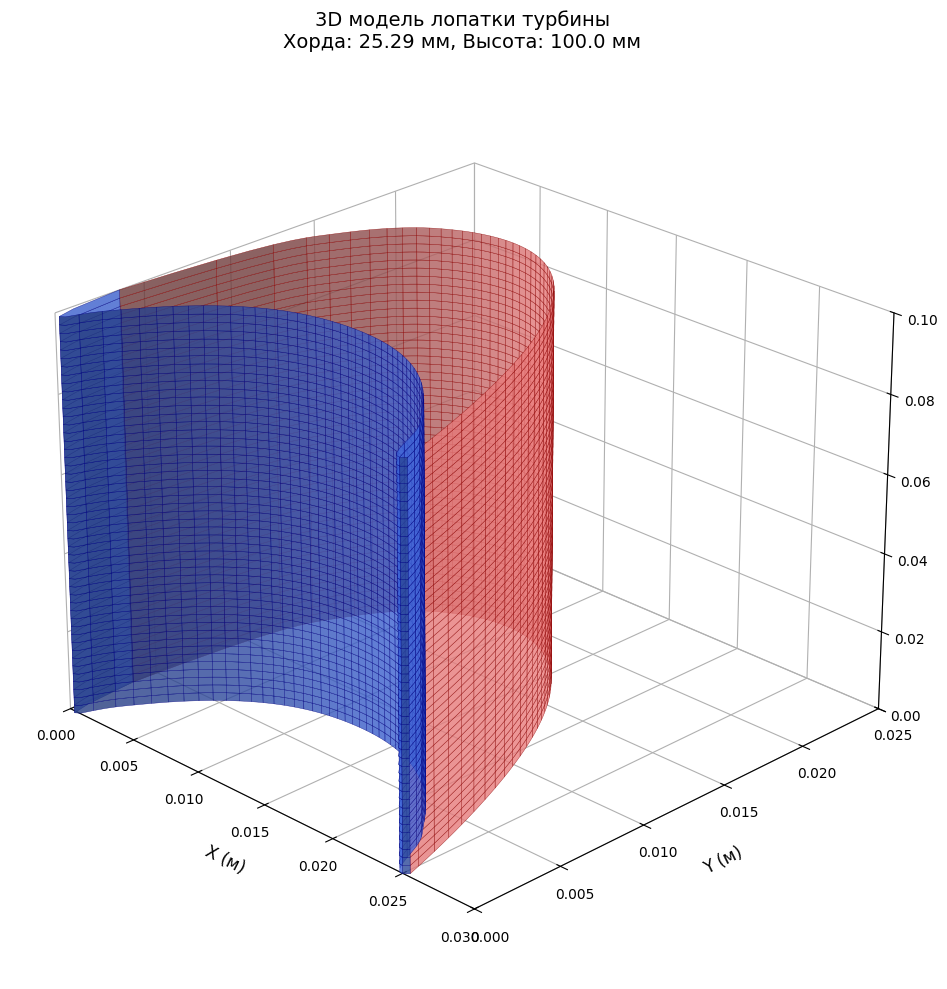

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import interp1d

xu_raw = np.array([0,0.45,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25.75,25.95])/1000
xl_raw = np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25.95])/1000
yu_raw = np.array([3.7,0.0,0.5,2.13,3.368,4.422,5.305,6.032,6.617,7.074,7.417,7.659,7.816,7.902,7.925,7.883,7.767,7.572,7.29,6.915,6.438,5.853,5.153,4.328,3.366,2.259,0,0.2])/1000
yl_raw = np.array([3.7,11.862,14.5,16.15,17.375,18.25,18.842,19.285,19.581,19.75,19.791,19.704,19.488,19.139,18.652,18.023,17.247,16.32,15.235,13.986,12.565,10.966,9.182,7.209,5.049,0.2])/1000

b_lop = 0.02529

scale_factor = b_lop / max(max(xu_raw), max(xl_raw))
xu = xu_raw * scale_factor
xl = xl_raw * scale_factor
yu = yu_raw * scale_factor
yl = yl_raw * scale_factor

blade_length = 0.1  
num_slices = 50  

f_upper = interp1d(xu, yu, kind='cubic', fill_value="extrapolate")
f_lower = interp1d(xl, yl, kind='cubic', fill_value="extrapolate")

x_fine = np.linspace(min(min(xu), min(xl)), max(max(xu), max(xl)), 100)
yu_fine = f_upper(x_fine)
yl_fine = f_lower(x_fine)

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

z_levels = np.linspace(0, blade_length, num_slices)

X_upper, Z_upper = np.meshgrid(x_fine, z_levels)
Y_upper = np.array([yu_fine] * num_slices)
ax.plot_surface(X_upper, Y_upper, Z_upper, color='royalblue', alpha=0.8, edgecolor='navy', linewidth=0.3)

X_lower, Z_lower = np.meshgrid(x_fine, z_levels)
Y_lower = np.array([yl_fine] * num_slices)
ax.plot_surface(X_lower, Y_lower, Z_lower, color='lightcoral', alpha=0.8, edgecolor='darkred', linewidth=0.3)

x_front = np.array([xu[0], xl[0]])
y_front = np.array([yu[0], yl[0]])
X_front, Z_front = np.meshgrid(x_front, z_levels)
Y_front = np.array([y_front] * num_slices)
ax.plot_surface(X_front, Y_front, Z_front, color='limegreen', alpha=0.7)

x_rear = np.array([xu[-1], xl[-1]])
y_rear = np.array([yu[-1], yl[-1]])
X_rear, Z_rear = np.meshgrid(x_rear, z_levels)
Y_rear = np.array([y_rear] * num_slices)
ax.plot_surface(X_rear, Y_rear, Z_rear, color='limegreen', alpha=0.7)

ax.set_xlabel('X (м)', fontsize=12, labelpad=10)
ax.set_ylabel('Y (м)', fontsize=12, labelpad=10)
ax.set_zlabel('Z (м)', fontsize=12, labelpad=10)
ax.set_title(f'3D модель лопатки турбины\nХорда: {b_lop*1000:.2f} мм, Высота: {blade_length*1000:.1f} мм', 
             fontsize=14, pad=20)

ax.view_init(elev=25, azim=-45) 

def set_axes_equal(ax):
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()
    
    x_range = abs(x_limits[1] - x_limits[0])
    y_range = abs(y_limits[1] - y_limits[0])
    z_range = abs(z_limits[1] - z_limits[0])
    
    plot_radius = 0.5*max([x_range, y_range, z_range])
    
    ax.set_xlim3d([0, 0.03])
    ax.set_ylim3d([0, 0.025])
    ax.set_zlim3d([0, blade_length])

set_axes_equal(ax)

# Добавляем сетку и улучшаем общее оформление
ax.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('w')
ax.yaxis.pane.set_edgecolor('w')
ax.zaxis.pane.set_edgecolor('w')

plt.tight_layout()
plt.show()